In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('../mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np
import pandas as pds
import math

In [2]:
R = 1
h = 1
lmax = np.sqrt((2*R)**2+h**2)
l = np.linspace(2*R,lmax,1000)
a = 1.3
p = (2*R/l)*np.power((1-(2*R/l)**2),(a-1)/2)
cLMax = l<lmax
p = p[cLMax]
l = l[cLMax]

In [3]:
#print(p)

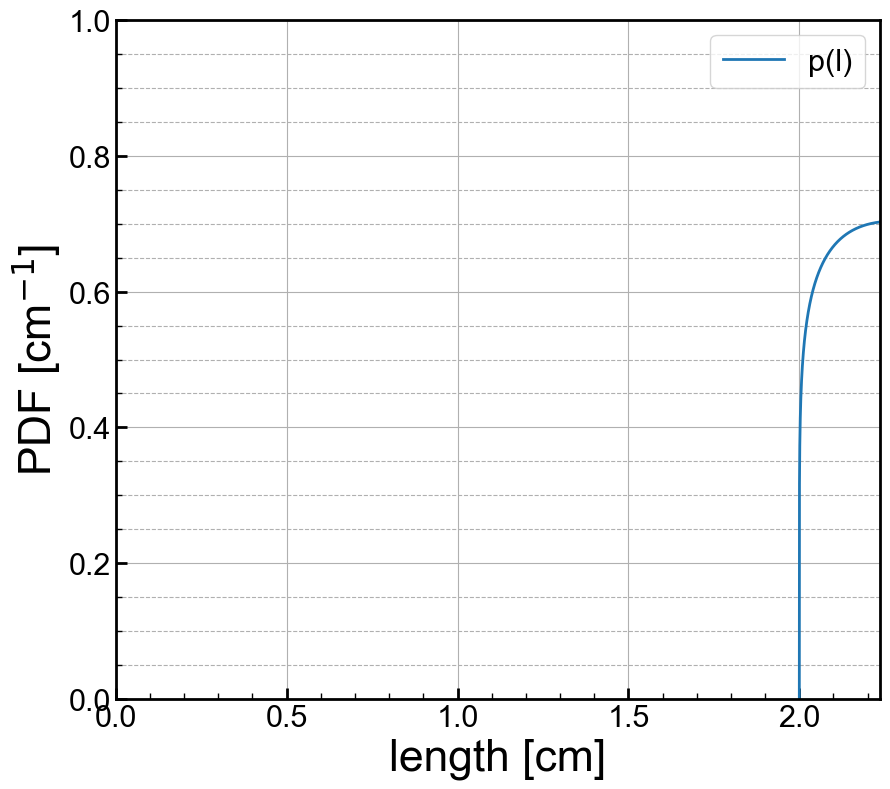

In [4]:
#set up a 1d plot
fig,axes = plt.subplots(1,1,figsize=(9.0,8.0),sharex=True)
ax1 = axes


#print(estring)
#ax1.plot(Er, dRlow,label='low res')
ax1.plot(l, p,label="p(l)")



ymin = 0
ymax = 1

blue = '#118DFA'
#ax1.fill_between(xcq,np.zeros(np.shape(xcq)),thist,step='mid',facecolor='b',alpha=0.4, \
#                 label='')

plt.grid()
ax1.set_yscale('linear')
#ax1.set_yscale('log')
ax1.set_xlim(0, lmax) 
ax1.set_ylim(ymin,ymax)
ax1.set_xlabel(r'length [cm]')
ax1.set_ylabel('PDF [cm$^{-1}$]')
ax1.grid(True)
ax1.yaxis.grid(True,which='minor',linestyle='--')
ax1.legend(loc=1,prop={'size':22})
#ax1.legend(bbox_to_anchor=(1.04,1),borderaxespad=0,prop={'size':22})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
#plt.savefig('figures/ne-recspec-Eee.png')
plt.show()

In [5]:
#the monte carlo way
L = 5
Nrad = 1000
X = np.random.uniform(-L,L,Nrad)
Y = np.random.uniform(-L,L,Nrad)
R0 = np.sqrt(X**2,Y**2)
#print(R0)

cOut = R0>R
R0 = R0[cOut]

In [6]:
from scipy import integrate
#def cos_int(x):
#  f = lambda u: (a+1)*np.power(u,a)
#  return integrate.quad(f,0,x)[0]

def cos_int(x):
    f = lambda u: (a + 1) * np.power(u, a)

    if np.isscalar(x):
        return integrate.quad(f, 0, x)[0]
    else:
        return np.array([integrate.quad(f, 0, xi)[0] for xi in x])

print(cos_int(0.9999999))

from scipy import optimize
#def inv_cos_int(y):
#  g = lambda v: cos_int(v)-y
#  return optimize.root(g,0.5).x[0]

def inv_cos_int(y):
    
    def solve_one(yi):
        g = lambda v: cos_int(v) - yi
        return optimize.root(g, 0.5).x[0]

    if np.isscalar(y):
        return solve_one(y)
    else:
        y = np.asarray(y)
        return np.array([solve_one(yi) for yi in y])

print(inv_cos_int([0.5,0.6]))
print(cos_int(0.8409))


0.999999770000015
[0.73980522 0.8008368 ]
0.6712928333118727


In [7]:
N = 1000
lall = []
for r in R0:
  #print(R/r)
  phi = np.random.uniform(-np.arcsin(R/r),np.arcsin(R/r),N)
  t = 2*np.sqrt(R**2 - r**2*np.sin(phi)**2)
  d = r*np.cos(phi) - np.sqrt(R**2 - r**2*np.sin(phi)**2)
  inv_costhet = np.random.uniform(0,1,N)
  costhet = inv_cos_int(inv_costhet)
  lcomp = t/np.sqrt(1-costhet**2)
  maxcos = h/np.sqrt((d+t)**2+h**2)
  cCos = (costhet>0)&(costhet<=maxcos)
  #print(R/(d[cCos]+t[cCos]))
  #print(t[cCos])
  #print(np.sqrt(1-costhet[cCos]**2))
  #print(lcomp[cCos])
  lall = np.append(lall,lcomp[cCos])


#inv_costhet = np.random.uniform(0,1,N)
#costhet = inv_cos_int(inv_costhet)
#print(lall)

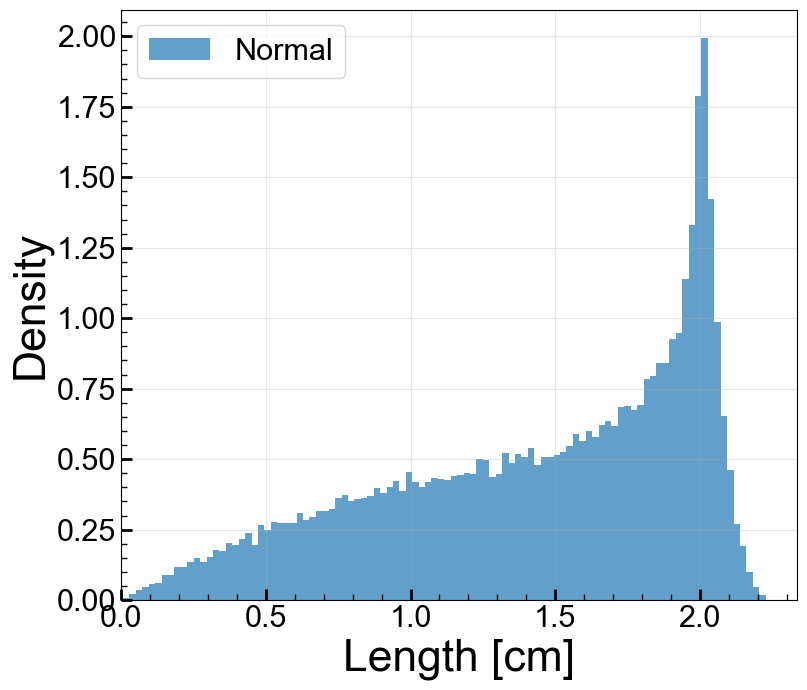

In [9]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 7))


xmax = np.sqrt((2*R)**2+h**2)+0.1
xplot = np.linspace(0,xmax, 10000)

ax1.hist(lall, bins=100, density=True, alpha=0.7, label='Normal',align='mid')


ax1.set_xlim(0.0, xmax) 
ax1.set_ylabel('Density')
ax1.set_xlabel('Length [cm]')
#ax1.set_title('Histogram of Chi-Square per DOF')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Adjust layout and save
plt.tight_layout()
plt.show()